# Lab 6

In this lab, we analyze the [tomato leaf disease detection](https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf) dataset from Kaggle using convolutional neural network architectures...

In [1]:
from IPython.display import display
from keras.utils import plot_model
from keras.saving import load_model

from pathlib import Path

from sklearn import datasets
from sklearn import metrics as mt
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras as keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers \
    import Activation, Conv2D, Dense, Dropout, Flatten, \
        Input, MaxPooling2D, RandomFlip, RandomRotation, Reshape

print('Tensorflow version:',tf.__version__)
print('Keras version:', keras.__version__)

print(tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.20.0
Keras version: 3.12.0
[]


**Warning:** We use saved models to avoid retraining on the same data unnecessarily. If you make changes from here on that may affect models, delete the relevant model to force retraining.

10


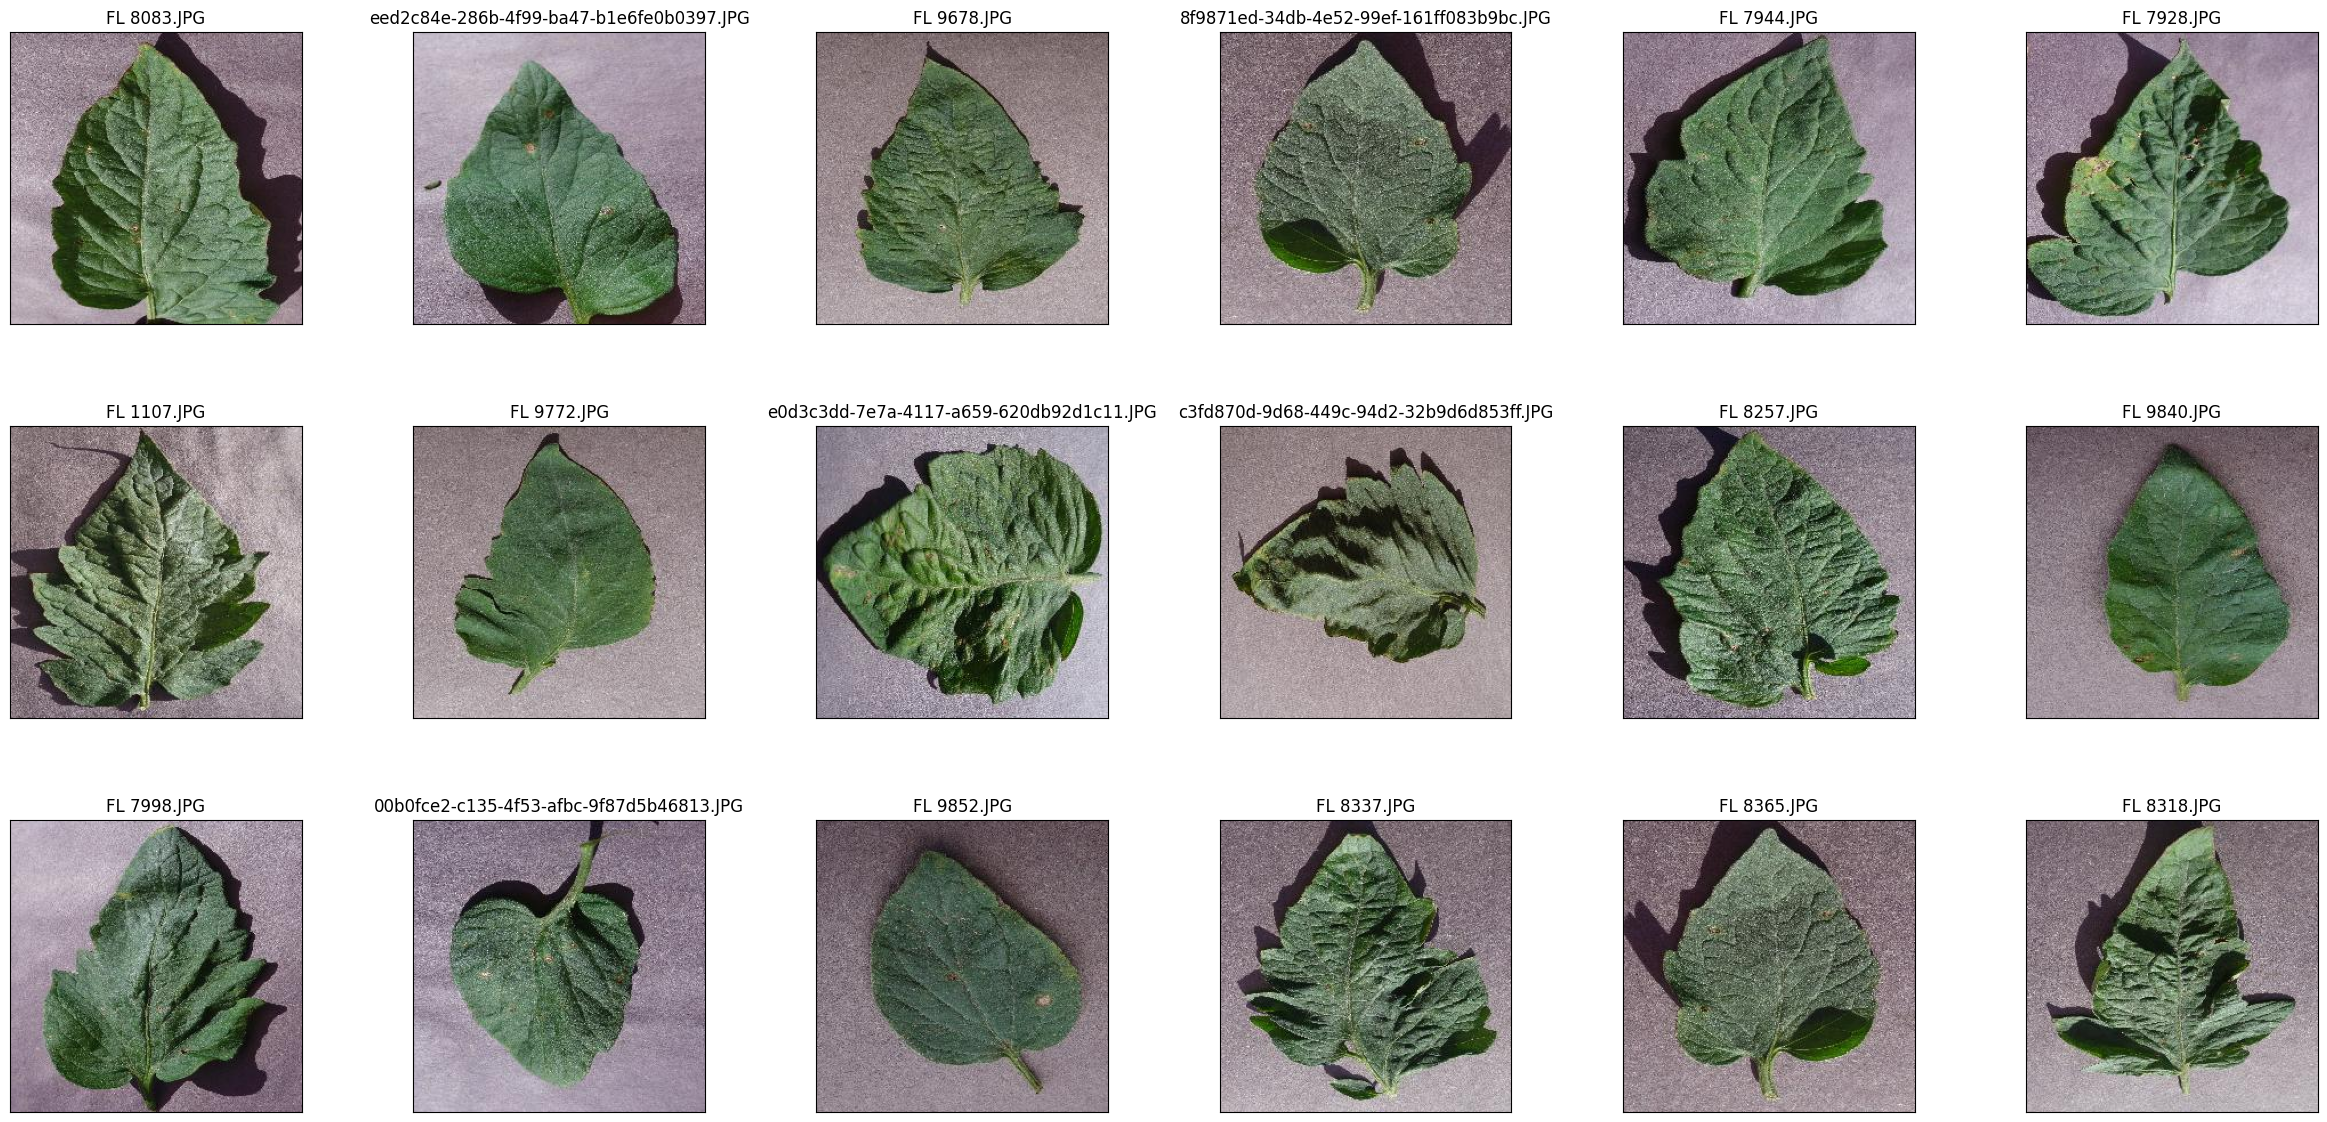

In [2]:
# Data preparation, as modified from Lab 2

from matplotlib.image import imread
from matplotlib import pyplot as plt
import glob
import os

images = []
target = []
names = []

flag_use_color = 1
# TODO: Enable this to test on everything
flag_use_all_data = 0

if flag_use_color:
    input_shape = (256, 256, 3)
else:
    input_shape = (256, 256)

if flag_use_all_data:
    path = glob.iglob('tomato/**/*.JPG', recursive=True)
else:
    path = glob.iglob('tomato/val/**/*.JPG', recursive=True)

# Courtesy of https://stackoverflow.com/a/12201744
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

done = False
for image_path in path:
    # Read in image
    img = imread(image_path)
    
    # Transform image
    if len(input_shape) < 3: img = rgb2gray(img)
    #flat_img = img.flatten()
    reshaped = img.reshape(input_shape)
    images.append(reshaped)

    p = os.path.normpath(image_path)
    f = os.path.basename(p)
    d = os.path.split(os.path.dirname(p))[-1]

    # Target name is the name after Tomato___ in directory
    target_name = d.split("___")[1].replace("_", " ")
    target.append(target_name)

    # Filenames are so long, only use the part after the last underscore
    names.append(f.split("_")[-1])

# Visualize some images
def plot_gallery(images, titles, n_row=3, n_col=6):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(4 * n_col, 4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        if len(input_shape) < 3:
            plt.imshow(images[i].reshape(input_shape), cmap=plt.cm.gray)
        else:
            plt.imshow(images[i].reshape(input_shape))
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())


# Normalization
X = np.array(images) / 255.0
plot_gallery(X, names)
X -= 0.5

from sklearn.preprocessing import LabelEncoder
np_target = np.array(target)
target_unique = np.unique(np_target)
NUM_CLASSES = len(target_unique)
print(NUM_CLASSES)

le = LabelEncoder()
le.fit(target_unique)
labels = list(le.classes_)
y = le.transform(np_target)

We began by loading all tomato leaf images from the Kaggle Tomato Disease Dataset. Each image was standardized to a resolution of 256×256 pixels. All pixel values were scaled to the (0,1) range and then centered around zero by subtracting 0.5. Due to the properties of the activation functions, without this normalization, our neural networks would completely fail to converge and always output the same class.

In [3]:
value_counts = pd.Series(np_target).value_counts()
display(pd.DataFrame(value_counts))

most_frequent_baseline = value_counts.max() / value_counts.sum()
print(most_frequent_baseline)

,count
Target Spot,100
Tomato mosaic virus,100
Leaf Mold,100
Bacterial spot,100
Early blight,100
healthy,100
Tomato Yellow Leaf Curl Virus,100
Spider mites Two-spotted spider mite,100
Septoria leaf spot,100
Late blight,95


0.10050251256281408


In this case, we believe that owing to the class distribution, accuracy is appropriate as there are far more disease classes compared to healthy classes, which accounts for the increased cost of false negatives already. In addition, the class balance ensures that no classes will be disregarded, so a metric like precision or recall does not offer advantages here.

In [4]:
# Split it into train / test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# and one hot encoding the output values
y_train_ohe = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = keras.utils.to_categorical(y_test, NUM_CLASSES)
        
# create a dataset 
ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train_ohe))
ds_train = ds_train.shuffle(1024) # buffer size for shuffle
ds_train = ds_train.batch(128)

ds_test  = tf.data.Dataset.from_tensor_slices((X_test, y_test_ohe))
ds_test = ds_test.batch(128)

For this project, we decided to use an 80/20 train–test split. Our dataset contains a large number of images, so using 80% of the data for training gives the model enough variation to learn all of the different feature representations. The performance of any model is strongly dependent on the diversity of samples, and 80% being used for training seems like enough to capture all of the different features of the image that can affect the model like different lighting or angles in the pictures.
The 20% test set is large enough to contain examples from every tomato disease class, ensuring stable accuracy measueres and allowing for a complete test of our model, without taking away too much of the data from the training portion.

In [5]:
def AugmentedSequential(name):
    model = Sequential(name = name)
    model.add( Input(input_shape) )
    
    # add in augmentations directly
    model.add(RandomFlip("horizontal"))
    model.add(RandomRotation(0.2))
    return model

In order to keep the models comparable, the input shape and the augmentation techniques will remain constant, so we'll define them in advance here.

These data augmentation techniques are justified because in real-world use, pictures would be taken in various formats and orientations. Our model should be resilient to this.

In [6]:
%matplotlib inline

def compare_models(models, ds_test, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)
    
    y_test = []
    for _, label_tensor in ds_test:
        # Convert the label tensor to a NumPy array and append it to the list
        y_test.append(label_tensor.numpy())
    y_test = np.argmax(np.vstack(y_test),axis=1) # stack into single array, get integer class

    # plot confusion matrices 
    num_plots = len(models)
    i = 1
    for model in models:
        yhat = np.argmax(model.predict(ds_test), axis=1)
        acc = mt.accuracy_score(y_test,yhat)

        cm = mt.confusion_matrix(y_test,yhat)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        
        plt.subplot(1,num_plots,i)
        
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels, yticklabels=labels)
        plt.title(f'{model.name}: {acc:.4f}')
        i += 1

def plot_confusion_matrix(model):
    compare_models((model, ), ds_test, fig_size = (6,6), labels = labels)

This function allows us to plot a confusion matrix to easily visualize the result of a neural network.

In [7]:
mlp = AugmentedSequential(name='StandardMultiLayerPerceptron')
mlp.add( Flatten() )
mlp.add( Dense(units=100, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(NUM_CLASSES) )
mlp.add( Activation('softmax') )

print(mlp.summary())

Model: "StandardMultiLayerPerceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    19,660,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,669,010 (75.03 MB)

 Trainable params: 19,669,010 (75.03 MB)

 Non-trainable params: 0 (0.00 B)

None


We create a standard multi-layer perceptron as a reference baseline to compare our convolutional neural networks to later.

In [8]:
def compile_model(model, basename, epochs, verbose):
    filename = Path("pretrain") / basename
    if filename.exists():
        return load_model(filename)
    model.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
    model.fit(ds_train,
            batch_size=32, epochs=epochs,
            shuffle=True, verbose=verbose)
    model.save(filename)
    return model

In [9]:
%%time

mlp = compile_model(mlp, "mlp.keras", 10, True)

CPU times: user 229 ms, sys: 235 ms, total: 464 ms
Wall time: 279 ms


2025-12-04 12:34:25.470119: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


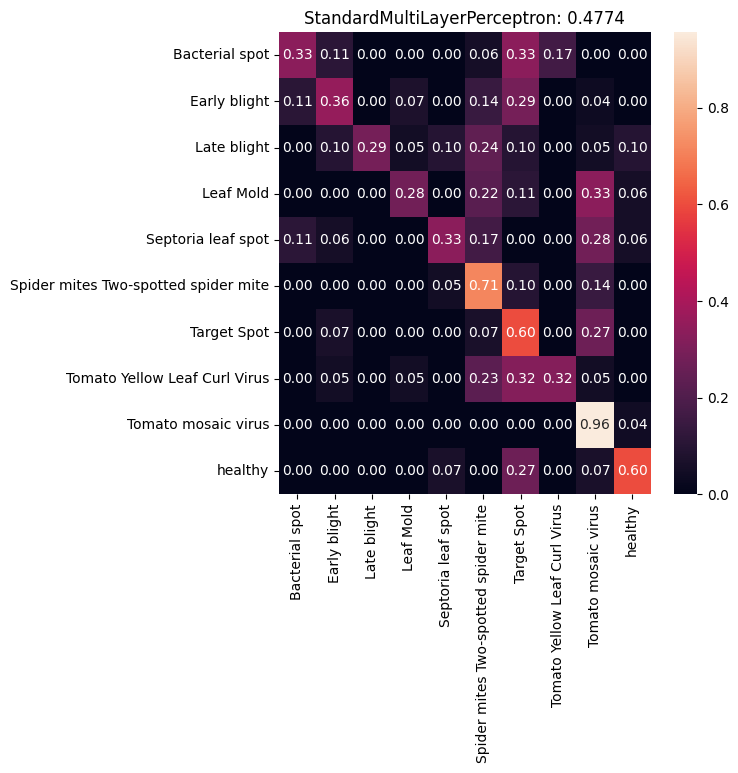

In [10]:
plot_confusion_matrix(mlp)

The accuracy from a standard MLP is a significant improvement over the most frequent classifier, with four sections having over 50% accuracy being reported. However, the overall accuracy of the model is still very poor and is incorrect over 50% of the time. While this is an improvement, this model is still not performing well enough to be used in any meaningful way.

In [11]:
%%time

# CREATE A CNN WITH ONLY ONE CONVOLUTIONAL LAYER AND ONE OUTPUT LAYER

# make a CNN with conv layer and max pooling
cnn = AugmentedSequential(name='2x2_Kernel')
cnn.add( Conv2D(filters=16, 
                kernel_size= (2, 2), 
                padding='same', 
               ) )

cnn.add( MaxPooling2D(pool_size=(2, 2)) )
cnn.add( Activation('relu') )
# add one layer on flattened output
cnn.add( Flatten() )
cnn.add( Dense(NUM_CLASSES) )
cnn.add( Activation('softmax') )

print(cnn.summary())

Model: "2x2_Kernel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │     2,621,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,658 (10.00 MB)

 Trainable params: 2,621,658 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

None
CPU times: user 56.3 ms, sys: 23.4 ms, total: 79.7 ms
Wall time: 57.4 ms


We create a convolutional neural network with just one convolution layer as a baseline to test other convolutional architectures.

In [12]:
%%time

cnn = compile_model(cnn, "cnn.keras", 150, False)

CPU times: user 75.2 ms, sys: 31.2 ms, total: 106 ms
Wall time: 128 ms


2025-12-04 12:34:26.939188: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step


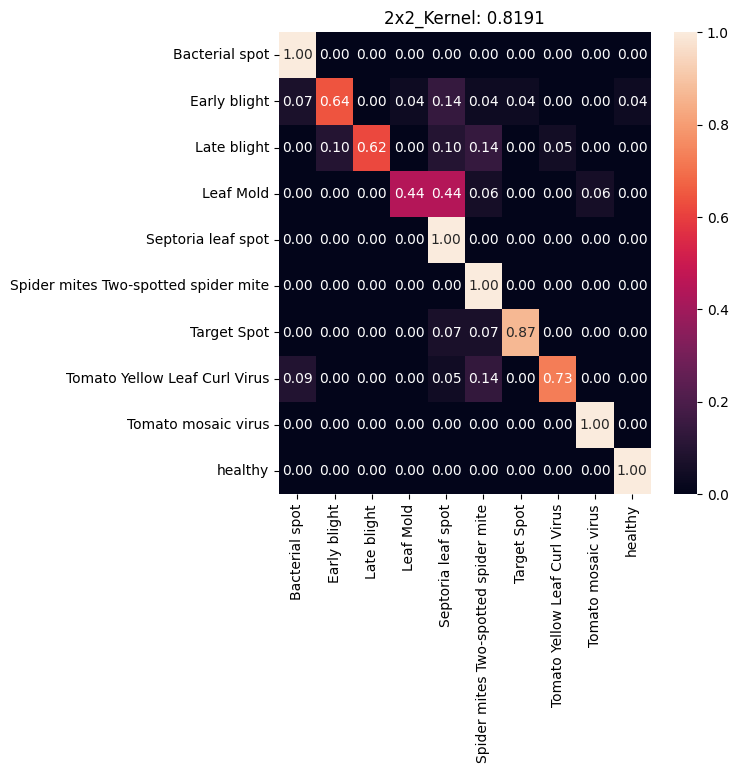

In [13]:
plot_confusion_matrix(cnn)

Even before any statistical tests, it is immediately visually apparent that this classification is much better and gives an immediate boost in accuracy when compared to the initial MLP. The accuracy raised from around 45% to 78%.

In [14]:
def create_cnn_model(model_name, input_shape, kernel_size= (3,3), pool_size=(2,2), 
                     filters_per_conv_layer = [32], # number of filters to use and how many convolutional layers to use 
                     dense_layer_sizes = [10], # number of neurons in each layer after flattening
                     use_dropout=False
                    ):
    
    cnn = AugmentedSequential(name=model_name)
    
    # convolutional layers
    for num_filters in filters_per_conv_layer:
        cnn.add( Conv2D(filters=num_filters, 
                        kernel_size=kernel_size, 
                        padding='same',
                        activation='relu',
                         ) )
        
        cnn.add( MaxPooling2D(pool_size=pool_size) )

    cnn.add( Flatten() )
    if len(dense_layer_sizes) > 1:
        # if layers preceding the final number of classes, make relu
        for num_hidden in dense_layer_sizes[:-2]:
            cnn.add( Dense(num_hidden, activation='relu') )
            # optionally use Dropout
            if use_dropout: cnn.add( Dropout(0.5) )
    # final layer for classes
    cnn.add( Dense(dense_layer_sizes[-1], activation='softmax') )

    return cnn

In [15]:
# changes: 
#    1. increased kernel size

cnn2 = create_cnn_model(
    model_name  = '3by3_kernel',
    input_shape = input_shape,
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32], 
    dense_layer_sizes      = [10], 
    use_dropout = False
)

print(cnn2.summary())

Model: "3by3_kernel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 524288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │     5,242,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,243,786 (20.00 MB)

 Trainable params: 5,243,786 (20.00 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
cnn3 = create_cnn_model(
    model_name  = '2_ConvLayer',
    input_shape = input_shape,
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,32], 
    dense_layer_sizes      = [10], 
    use_dropout = False
)

print(cnn3.summary())

Model: "2_ConvLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,874 (5.04 MB)

 Trainable params: 1,320,874 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
cnn4 = create_cnn_model(
    model_name  = '2_ConvLayer_2Dense',
    input_shape = input_shape,
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [16,32], 
    dense_layer_sizes      = [100,10], 
    use_dropout = True
)

print(cnn4.summary())

Model: "2_ConvLayer_2Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,818 (5.02 MB)

 Trainable params: 1,315,818 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

None


We now create three more convolutional networks to investigate the effects of changing various parameters. In the first network, we increased the size of the kernel to see how that would affect accuracy. For the next model, we added a convolutional layer while making the nuber of filters 32. For the last model, we created it with 2 convolutional layers and 2 dense layers.

In [18]:
%%time

cnn2 = compile_model(cnn2, "cnn2.keras", 150, False)

CPU times: user 74.1 ms, sys: 52.7 ms, total: 127 ms
Wall time: 71.2 ms


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x15ad40d60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step


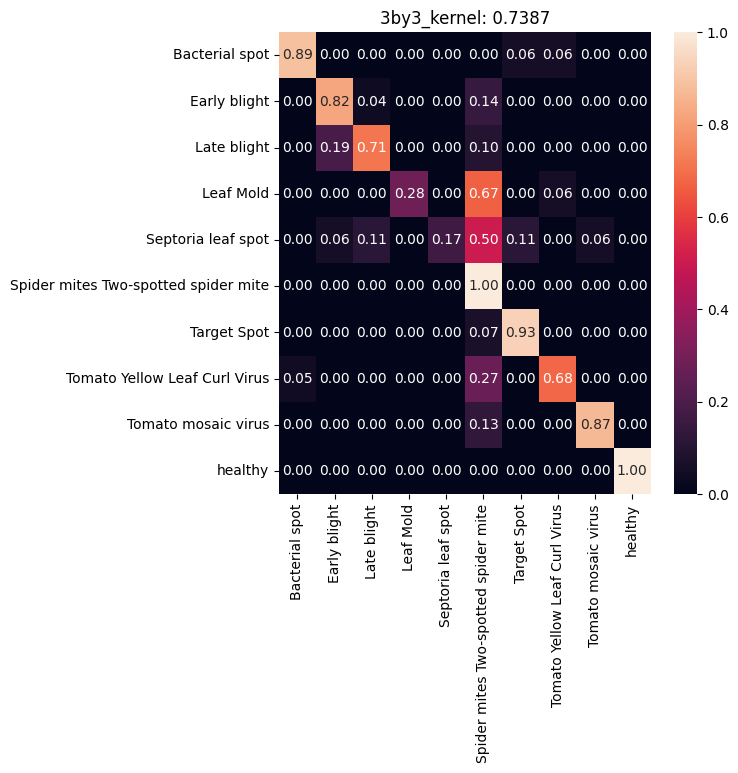

In [19]:
plot_confusion_matrix(cnn2)

These are the results from the first new model where the kernel size increased. This actually resulted in a lower accuracy than the base model with an accuracy of 75%, which was a surprising result to us.

In [20]:
%%time

cnn3 = compile_model(cnn3, "cnn3.keras", 150, False)

CPU times: user 48.3 ms, sys: 19.9 ms, total: 68.2 ms
Wall time: 50.8 ms


2025-12-04 12:34:29.381076: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step


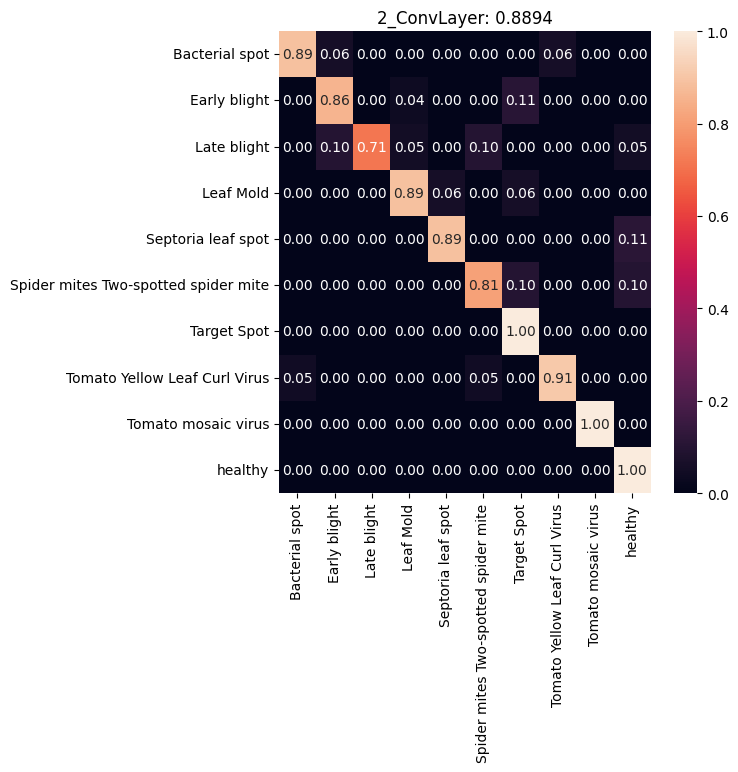

In [21]:
plot_confusion_matrix(cnn3)

These are the results for the model that we creted with 2 convolutional layers, which resulted in an accuracy of 86%. This is the kind of accuracy results we expect to see as it shows us that adding more layers increases increases the accuracy of the model as we expected.

In [22]:
cnn4 = compile_model(cnn4, "cnn4.keras", 150, False)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


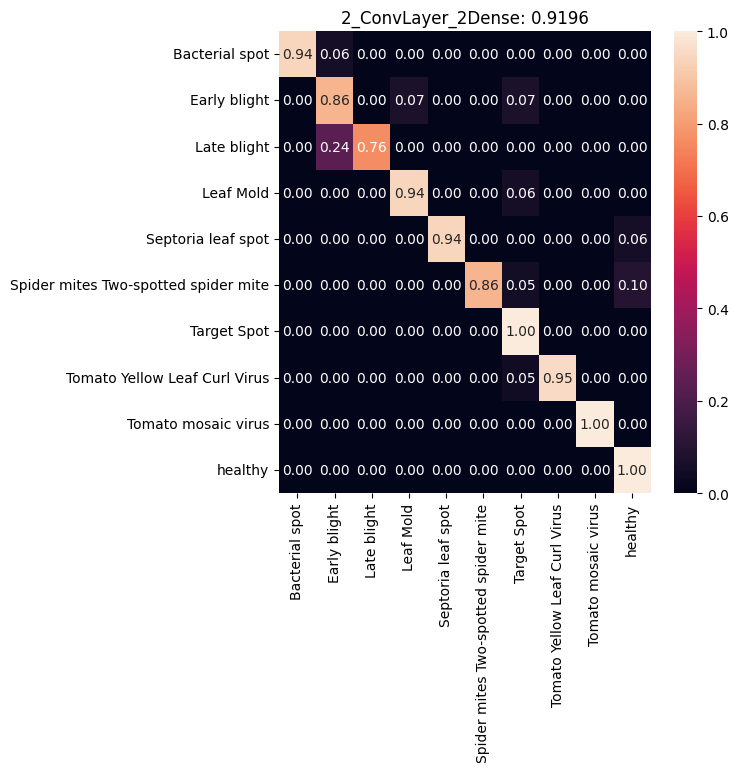

In [23]:
plot_confusion_matrix(cnn4)

This is the model with 2 convolutional layers and two dense layers, which performed the best. This does not suprise  us and shows us that the number of layers has the most impact on a model's performance, instead of kernel size or the number of filters.

In [24]:
# This code is adapted from Lab 5 with very few changes.

from itertools import combinations
from scipy import stats

# Survival function (1 - cdf): yields p-value from test statistic
# For instance, 3.841 would yield p = 0.05
chi2_p_value = stats.chi2.sf

def mcnemar_table(y_target, y_model1, y_model2):
    table = np.zeros((2, 2))
    for y, yhat1, yhat2 in zip(y_target, y_model1, y_model2):
        index1 = (1 if yhat1 == y else 0)
        index2 = (1 if yhat2 == y else 0)
        table[index1, index2] += 1
    return table

def mcnemar(table, corrected = True, exact = False):
    b = table[0, 1]
    c = table[1, 0]

    # Use a binomial test when appropriate
    if exact:
        n_min, n_max = sorted([b, c])
        p = (2 * stats.binom.cdf(n_min, n_min + n_max, 0.5) - 
            stats.binom.pmf(n_min, n_min + n_max, 0.5))
        return None, p

    if corrected:
        # Continuity correction from Edwards (1948)
        chi2 = ((abs(b - c) - 1) ** 2) / (b + c)
    else:
        # Original test statistic
        chi2 = ((b - c) ** 2) / (b + c)
    p = chi2_p_value(chi2, df = 1)
    return chi2, p

def mcnemar_test(y_target, model1, model2):
    table = mcnemar_table(y_target = y_test, y_model1 = model1, y_model2 = model2)
    print(table)
    n = table[0, 1] + table[1, 0]
    return mcnemar(table, corrected = True, exact = n < 25)

def test_models(y_test, alpha, models, names):
    for a, b in combinations(range(len(models)), 2):
        model1, name1, model2, name2 = (models[a], names[a], models[b], names[b])
        chi2, p = mcnemar_test(y_test, model1, model2)
        if chi2 is None:
            print("p = %0.10f for %s and %s so result is%s significantly different" %
                (p, name1, name2, "n't" if p > alpha else ""))
        else:
            print("\u03c7\u00b2 = %0.4f, p = %0.10f for %s and %s so result is%s significantly different" %
                (chi2, p, name1, name2, "n't" if p > alpha else ""))

In [25]:
compare_models = [mlp, cnn, cnn2, cnn3, cnn4]

yhat0 = []
yhat = []

for model in compare_models:
    model_yhat0 = model.predict(ds_test)
    model_yhat = np.argmax(model_yhat0, axis = 1)

    yhat0.append(model_yhat0)
    yhat.append(model_yhat)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [26]:
test_models(y_test, 0.05, yhat,
            ["Baseline MLP", "2x2 Kernel CNN", "3x3 Kernel CNN",
            "2 convolution 3x3 CNN", "2 dense layer, 2 convolution 3x3 CNN"])

[[31. 73.]
 [ 5. 90.]]
χ² = 57.5513, p = 0.0000000000 for Baseline MLP and 2x2 Kernel CNN so result is significantly different
[[40. 64.]
 [12. 83.]]
χ² = 34.2237, p = 0.0000000049 for Baseline MLP and 3x3 Kernel CNN so result is significantly different
[[16. 88.]
 [ 6. 89.]]
χ² = 69.7979, p = 0.0000000000 for Baseline MLP and 2 convolution 3x3 CNN so result is significantly different
[[13. 91.]
 [ 3. 92.]]
χ² = 80.5213, p = 0.0000000000 for Baseline MLP and 2 dense layer, 2 convolution 3x3 CNN so result is significantly different
[[ 25.  11.]
 [ 27. 136.]]
χ² = 5.9211, p = 0.0149610177 for 2x2 Kernel CNN and 3x3 Kernel CNN so result is significantly different
[[ 14.  22.]
 [  8. 155.]]
χ² = 5.6333, p = 0.0176220910 for 2x2 Kernel CNN and 2 convolution 3x3 CNN so result is significantly different
[[ 11.  25.]
 [  5. 158.]]
χ² = 12.0333, p = 0.0005225754 for 2x2 Kernel CNN and 2 dense layer, 2 convolution 3x3 CNN so result is significantly different
[[ 16.  36.]
 [  6. 141.]]
χ² = 20.02

This confirms our previous conclusion that the number of layers has much more of an effect on a model rather than the number of filters or kernel size. ALl of the models performed significantly better than the base models in a statistically significant way, while the two models with more layers significantly outperformed the others.

In [27]:
for yhat in yhat0:
    print(mt.roc_auc_score(y_test, yhat, multi_class = 'ovr'))

0.8445090176958562
0.9882213772164633
0.9794570695401514
0.9919123206721675
0.9967563365885705


In [28]:
from itertools import cycle
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

def plot_multiclass_roc(y_score, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    fpr, tpr, roc_auc = dict(), dict(), dict()

    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_test_ohe[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.subplot()

    colors = cycle(['tab:blue', 'tab:green', 'tab:red',
        'tab:cyan', 'tab:pink', 'tab:olive',
        'tab:orange', 'tab:purple', 'tab:brown',
        'tab:gray'])
    for class_id, color in zip(range(NUM_CLASSES), colors):
        RocCurveDisplay.from_predictions(
            y_test_ohe[:, class_id],
            y_score[:, class_id],
            name=f"ROC curve for {labels[class_id]}",
            curve_kwargs=dict(color=color),
            ax=ax,
            plot_chance_level=(class_id == 2),
            despine=True,
        )
    
    _ = ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=title,
    )


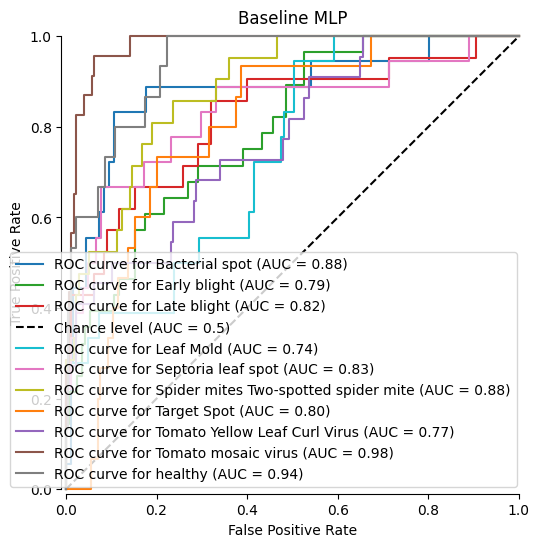

In [29]:
plot_multiclass_roc(yhat0[0], "Baseline MLP")

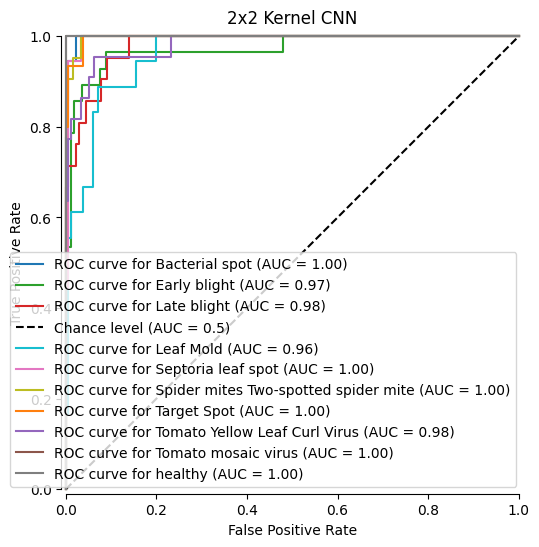

In [30]:
plot_multiclass_roc(yhat0[1], "2x2 Kernel CNN")

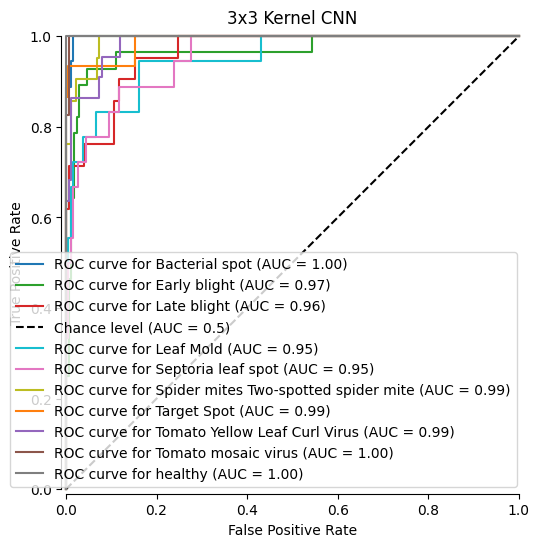

In [31]:
plot_multiclass_roc(yhat0[2], "3x3 Kernel CNN")

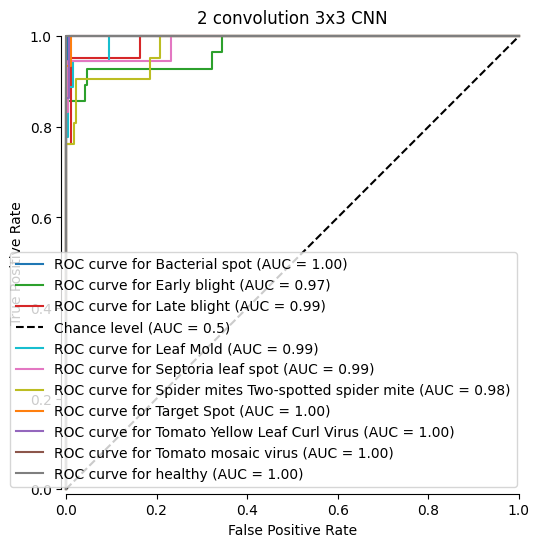

In [32]:
plot_multiclass_roc(yhat0[3], "2 convolution 3x3 CNN")

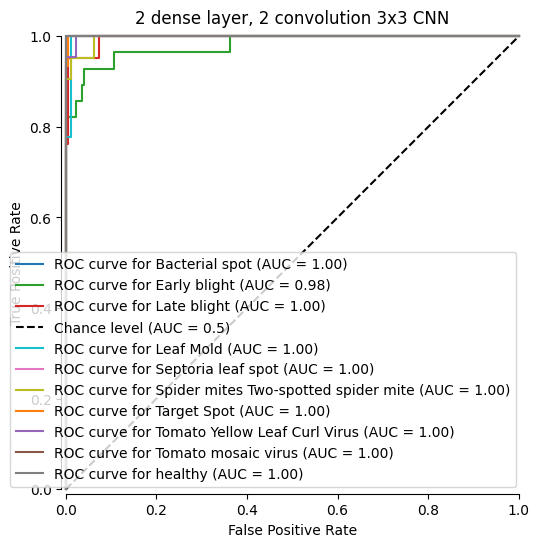

In [33]:
plot_multiclass_roc(yhat0[4], "2 dense layer, 2 convolution 3x3 CNN")

It appears that early blight remains difficult to classify, but as expected, the final classifier is an excellent choice overall.